In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk
import numpy as np

from netket.experimental.dynamics import RK45

from callbacks import (
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
    get_umbrella_monitor_callback,
)
from logger import Logger

/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Use driver.run(..., timeit=True) to know where your dominant cost is.

# Define the variational state
The variational state is given by
$$|\psi_{\alpha,\beta}\rangle = \alpha |0\rangle +  \beta |0\rangle$$

In [ ]:
import flax.linen as nn
import jax.numpy as jnp
from netket.hilbert import DiscreteHilbert

class AlphaBetaState(nn.Module):
    r"""Tiny Flax model with two scalar trainable parameters (alpha, beta).
    Intended to demonstrate initialization from python floats.
    """
    hilbert: DiscreteHilbert
    alpha0: complex = 0.0
    beta0: complex = 0.0

    @nn.compact
    def __call__(self, x_in):
        """Return a batch of log-psi values."""
        assert self.hilbert.size==1., "Only works for single qubit state"
        alpha = self.param("alpha", nn.initializers.constant(self.alpha0, dtype=complex), ())
        beta = self.param("beta", nn.initializers.constant(self.beta0, dtype=complex), ())
        out = jnp.where(x_in==1, alpha, beta)
        return jnp.log(out).squeeze()
    
hilbert = nk.hilbert.Spin(s=1 / 2, N=1)

def get_vstate(n_samples):
    # Small system because the dense S-matrix scales like O(N_params^2).
    # Increase L/alpha only if you really need the full dense matrix.
    seed = 100

    # Hilbert space: L spin-1/2 sites
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains = n_samples)

    # Model initialized from two python floats -> trainable params start at these values
    model = AlphaBetaState(
        hilbert=hilbert,
        alpha0=1.0,
        beta0=1.0,
    )

    # Variational Monte Carlo state
    vstate = nk.vqs.MCState(
        sampler=sampler,
        model=model,
        n_samples=n_samples,
        seed=seed
    )
    x = vstate.sample(n_samples=n_samples)
    psi = vstate.to_array()
    print(psi)
    return vstate

# Set up Hamiltonian
The Hamiltonian is 

$$H = \sigma^y$$

In [12]:


fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)

hamiltonian = nk.operator.PauliStringsJax(hilbert, "Y", 1.)
sigma_z = nk.operator.PauliStringsJax(hilbert, "Z", 1.)

def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_z)
    return True

# Plot function
def plot(save_path):
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    (ax_snr, ax_snrF) = axs[0]
    (ax_z, ax_ess) = axs[1]
    ax_z.plot(logger.data["t"]["values"], np.array(logger.data["sigma_z"]["Mean"]).real)
    ax_z.set_xlabel("t")
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")

    x_vals = logger.data["t"]["values"]
    ess_vals = logger.data["ess_bridge"]["values"]
    q_vals = logger.data["q_bridge"]["values"]
    if ess_vals and q_vals:
        # print(ess_vals)
        ax_right = ax_ess.twinx()
        (line1,) = ax_ess.plot(x_vals, ess_vals, color="tab:blue", label="ESS (bridge)")
        # Also plot max_weight_over_mean on left axis
        (line2,) = ax_right.plot(x_vals, q_vals, color="tab:orange", label="q (bridge)")
        target_ess = 0.1
        ax_right.axhline(
            target_ess,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=f"ess target = {target_ess:1.2f}",
        )

        ax_ess.set_xlabel("Step")
        ax_ess.set_ylabel("ESS (bridge)", color="tab:blue")
        ax_right.set_ylabel("q (bridge)", color="tab:orange")
        ax_ess.set_yscale("log")
        ax_right.set_ylim(-0.05, 1.1)
        ax_ess.grid(True, alpha=0.3)
        ax_ess.set_title("Bridge ESS, q")

        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        # Include max_weight_over_mean if present
        ax_ess.legend(
            lines + [ax_right.lines[-1]],
            labels + [f"ess target = {target_ess:1.2f}"],
            loc="best",
        )

    # Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
    snr_len = len(logger.data.get("snr", {}).get("values", []))
    cmap_snr = plt.get_cmap("Purples")
    # Normalize step index to [0,1] for colorbar
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.)
    for i in range(snr_len):
        snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
        frac = 0.0 if snr_len <= 1 else i / 20
        ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
    # Summary lines from monitor
    snr_med_series = logger.data.get("snr_med", {}).get("values", [])
    snr_min_series = logger.data.get("snr_min", {}).get("values", [])
    if len(snr_med_series) > 0:
        ax_snr.axhline(
            np.array(snr_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    ax_snr.set_xlabel(r"Mode index $k$")
    ax_snr.set_ylabel("SNR (eigenbasis)")
    ax_snr.set_title(rf"SNR($\rho_k$) over time")
    ax_snr.set_yscale("log")
    # ax_snr.set_ylim([1e-6, 1e7])
    ax_snr.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    cmap_snr = plt.get_cmap('Purples')
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
    sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
    sm_snr.set_array([])
    fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

    # Top-middle: SNR(F) sorted curves with log y; add median and min lines
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("Blues")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        # print(snr_F_data)
        frac = 0.0 if snrF_len <= 1 else i / 20
        ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    if len(snrF_med_series) > 0:
        ax_snrF.axhline(
            np.array(snrF_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snrF_min_series) > 0:
    #     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snrF.set_xlabel(r"Parameter index $k$")
    ax_snrF.set_ylabel("SNR(F)")
    ax_snrF.set_title(rf"SNR(F) over time")
    ax_snrF.set_yscale("log")
    # ax_snrF.set_ylim([1e-2, 1e2])
    ax_snrF.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
    sm_snrF.set_array([])
    plt.tight_layout()
    plt.show()

## Standard Dynamics
Run the dynamics with the regularizer from Schmitt.

In [21]:
from schmitt_tdvp import TDVPSchmitt

n_samples_tvmc = 2**14
T = 2.
save_times = np.linspace(0.0, T, 20)
exp_name = "fixed"
# Make sure we always start with the same state in notebook

vstate = get_vstate(n_samples_tvmc)
save_path = f"./data/SIGMA_Y/{exp_name}/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

logger = Logger(path=save_path, fields=fields_to_track)

callbacks = [ ]
callbacks.append(measure_sigma_z)
tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
callbacks.append(tdvp_monitor_callback)
integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
tvmc_kwargs = {}
driver = TDVPSchmitt(
    hamiltonian,
    vstate,
    integrator,
    t0=0,
    holomorphic=False,
    snr_atol=2,
    rcond=1e-14,
    rcond_smooth=1e-10,
    **tvmc_kwargs,
)

driver.run(
    T,
    out=logger,
    callback = callbacks,
    show_progress=True,
    timeit=True,
)
logger.flush()


[0.70710678+0.j 0.70710678+0.j]


  0%|          | 0.00/2.00 [00:00<?, ?it/s]

100%|██████████| 2.00/2.00 [01:33<00:00, 46.7s/it, n=2000, Generator=-0.0000+0.0063j ± 0.0078 [σ²=1.0e+00]]                                                                                                         


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 93.401                                                                                                   │
│ ├── (1.9%) | MCState.expect : 1.776 s                                                                           │
│ ├── (21.7%) | MCState.local_estimators : 20.301 s                                                               │
│ │   └── (48.6%) | MCState.sample : 9.870 s                                                                      │
│ │       └── (40.1%) | sampling n_discarded samples : 3.962 s                                                    │
│ ├── (5.0%) | QGTJacobian_DefaultConstructor : 4.675 s                                                           │
│ │   └── (32.4%) | jacobian : 1.513 s                                                                            │
│ └── (11.3%) | _impl : 10.545 s                                        

Restored: True
[nan]
[298.93285214 298.93276736 298.93285214 298.93276736]
[144.05630533 144.05628413 144.05630533 144.05628413]
[87.14679313 87.14678435 87.14679313 87.14678435]
[56.71587593 56.71587139 56.71587593 56.71587139]
[36.12468852 36.12468601 36.12468852 36.12468601]
[20.656313   20.65631173 20.656313   20.65631173]
[6.58338417 6.5833838  6.58338417 6.5833838 ]
[inf inf inf inf]
[inf inf inf inf]
[inf inf inf inf]
[inf inf inf inf]
[inf inf inf inf]
[inf inf inf inf]
[inf inf inf inf]
[5.67348934 5.67348904 5.67348934 5.67348904]
[19.00702236 19.00702113 19.00702236 19.00702113]
[35.85195633 35.85195392 35.85195633 35.85195392]
[55.2913849  55.29138053 55.2913849  55.29138053]
[84.4746802  84.47467185 84.4746802  84.47467185]


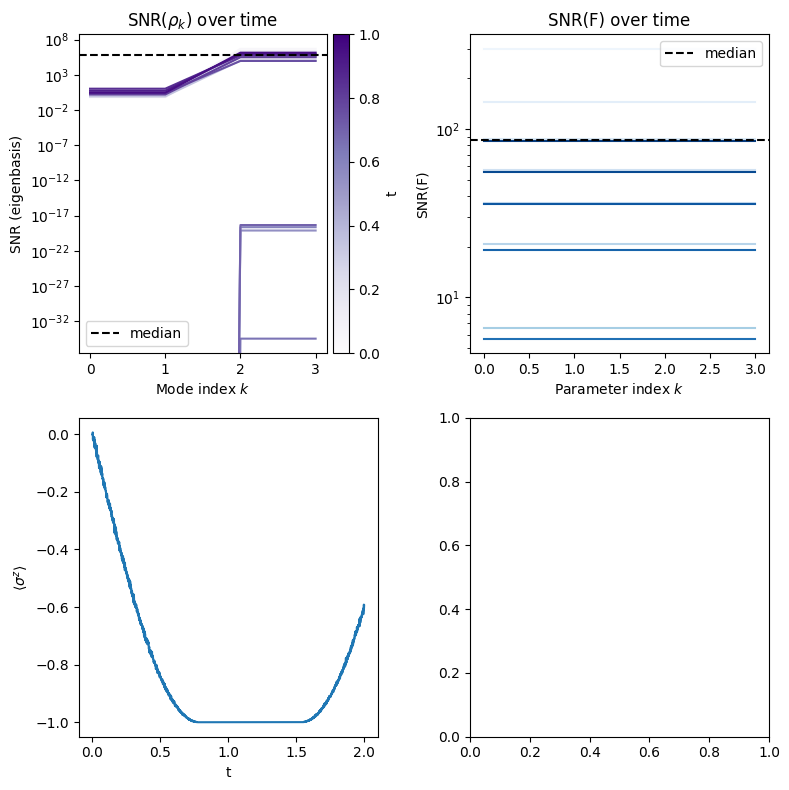

In [23]:
exp_name = "fixed"
save_path = f"./data/SIGMA_Y/{exp_name}/"
plot(save_path)

# Bridge dynamics
Run the dynamics with the bridge sampler and the Schmitt regularizer

In [10]:
from schmitt_tdvp_bridge import TDVPSchmittBridge

n_samples_tvmc = 2**10
T = 2.
save_times = np.linspace(0.0, T, 20)
exp_name = "bridge"
# Make sure we always start with the same state in notebook

vstate = get_vstate(n_samples_tvmc)
vstate.chunk_size = 64
save_path = f"./data/SIGMA_Y/{exp_name}/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

logger = Logger(path=save_path, fields=fields_to_track)

callbacks = [ ]
callbacks.append(measure_sigma_z)
callbacks.append(get_parameter_save_callback(save_times, logger))
tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
callbacks.append(tdvp_monitor_callback)

integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
tvmc_kwargs = {}
# thermalize
for i in range(100):
    vstate.sample()
print(vstate.expect(sigma_z))
driver = TDVPSchmittBridge(
    hamiltonian,
    vstate,
    integrator,
    t0=0,
    q0=1.,
    q_min=0.1,
    ess_target=10,
    holomorphic=False,
    snr_atol=2,
    rcond=1e-14,
    rcond_smooth=1e-10,
    **tvmc_kwargs,
)

driver.run(
    T,
    out=logger,
    callback = callbacks,
    show_progress=True,
    timeit=True,
)
logger.flush()


[0.70710678+0.j 0.70710678+0.j]
0.025+0.000j ± 0.031 [σ²=1.0e+00]


  0%|          | 0.00/2.00 [00:00<02:05, 62.8s/it, n=1, Generator=0.000-0.008j ± 0.031 [σ²=1.0e+00]]

Saved parameters...


  5%|▌         | 0.11/2.00 [00:06<01:53, 59.9s/it, n=108, Generator=0.000-0.008j ± 0.031 [σ²=9.7e-01]]

Saved parameters...


...

 95%|█████████▍| 1.90/2.00 [01:48<00:05, 56.9s/it, n=1899, Generator=-0.000+0.030j ± 0.025 [σ²=6.5e-01]]

Saved parameters...


100%|██████████| 2.00/2.00 [01:52<00:00, 56.0s/it, n=2000, Generator=-0.000-0.032j ± 0.024 [σ²=5.9e-01]]


Saved parameters...


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 112.080                                                                                                  │
│ ├── (2.0%) | MCState.expect : 2.231 s                                                                           │
│ ├── (8.4%) | MCState.sample : 9.410 s                                                                           │
│ │   └── (40.8%) | sampling n_discarded samples : 3.844 s                                                        │
│ ├── (8.2%) | QGTJacobian_DefaultConstructor : 9.171 s                                                           │
│ │   └── (45.2%) | jacobian : 4.146 s                                                                            │
│ └── (10.4%) | _impl : 11.633 s                                                                                  │
╰───────────────────────────────────────────────────────────────────────

Restored: True


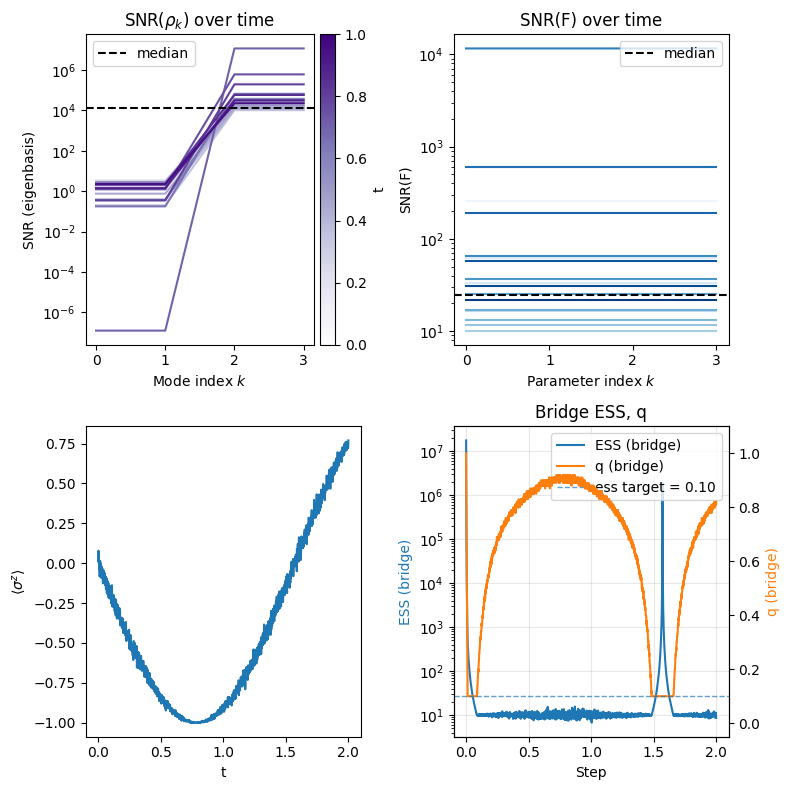

In [11]:
exp_name = "bridge"
save_path = f"./data/SIGMA_Y/{exp_name}/"
plot(save_path)